# 07 — Null Geodesics: Photon Capture, Scattering, and a Simple Capture Map

The timelike calculations in the earlier notebooks use

\[
g_{\mu\nu}u^\mu u^\nu=-1.
\]

Photon trajectories follow the same geodesic equation, but their tangent vector
\(k^\mu\) is null,

\[
g_{\mu\nu}k^\mu k^\nu=0.
\]

This notebook uses the validated Cartesian Kerr–Schild geodesic engine to study
three null-geodesic problems:

1. photon capture and scattering in Schwarzschild spacetime;
2. the prograde/retrograde capture asymmetry produced by Kerr spin;
3. a finite-distance parallel-ray capture map, which provides a simple
   shadow-like diagnostic.

The final capture maps are not radiative-transfer images. They classify whether
initially parallel rays cross the event horizon or return to the launch radius.


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from kerr_schild_geodesics import (
    CAPTURED,
    ESCAPED,
    UNRESOLVED,
    horizon_radius,
    kerr_radius,
    normalization,
    energy_lz,
    parallel_ray_state,
    trace_null_ray,
    parallel_capture_map,
)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)


Project root: /home/allanur/Desktop/kerr-schild-geodesics


## 1. Null initial conditions

A ray is launched from \(x=-40M\) toward \(+x\). The screen coordinates
\((y_0,z_0)\) control its asymptotic offset from the black hole.

The spatial scale of a null tangent vector is arbitrary because the affine
parameter may be rescaled. The code sets

\[
k^x=1,\qquad k^y=k^z=0,
\]

and solves the null-normalization quadratic equation for the future-directed
\(k^t\).


In [2]:
M = 1.0

ray_test = parallel_ray_state(
    -40.0,
    7.0,
    0.0,
    M=M,
    a=0.0,
)

print("null normalization =", normalization(ray_test, M, 0.0))
print("E, Lz =", energy_lz(ray_test, M, 0.0))


null normalization = 0.0
E, Lz = (0.9992679780863521, -7.0)


## 2. Schwarzschild photon capture and scattering

For Schwarzschild spacetime, the critical impact parameter for photons
arriving from infinity is

\[
b_{\rm crit}=3\sqrt{3}\,M\approx5.196M.
\]

The rays below begin at a large but finite distance, so the screen offset
\(y_0\) is not exactly the invariant impact parameter \(L_z/E\). The conserved
ratio \(L_z/E\) is printed for each ray.

Three representative cases are used:

- \(y_0=5.0M\): capture;
- \(y_0=5.20M\): near-critical strong deflection;
- \(y_0=7.0M\): ordinary scattering.


In [3]:
def trace_parallel_ray(
    y0,
    z0,
    a,
    x0=-40.0,
    h=0.02,
    lambda_max=160.0,
):
    state0 = parallel_ray_state(
        x0,
        y0,
        z0,
        M=M,
        a=a,
    )

    n_steps = int(lambda_max / h)

    full, used, outcome = trace_null_ray(
        state0,
        h,
        n_steps,
        M=M,
        a=a,
    )

    trajectory = full[:used]

    E, Lz = energy_lz(
        state0,
        M,
        a,
    )

    return trajectory, outcome, E, Lz


schwarzschild_cases = [
    ("capture", 5.00),
    ("near-critical scatter", 5.20),
    ("wide scatter", 7.00),
]

schwarzschild_rays = {}

for label, y0 in schwarzschild_cases:
    ray, outcome, E, Lz = trace_parallel_ray(
        y0,
        0.0,
        a=0.0,
    )

    schwarzschild_rays[label] = ray

    outcome_name = {
        CAPTURED: "captured",
        ESCAPED: "scattered/escaped",
        UNRESOLVED: "unresolved",
    }[outcome]

    r_values = np.sqrt(
        ray[:,1]**2
        + ray[:,2]**2
        + ray[:,3]**2
    )

    print(label)
    print("  outcome =", outcome_name)
    print("  Lz/E =", Lz/E)
    print("  minimum r/M =", r_values.min())


capture
  outcome = captured
  Lz/E = -5.001909319780026
  minimum r/M = 1.9999989208954274
near-critical scatter
  outcome = scattered/escaped
  Lz/E = -5.202143784807361
  minimum r/M = 3.0863039173823013
wide scatter
  outcome = scattered/escaped
  Lz/E = -7.00512790713593
  minimum r/M = 5.622966491506813


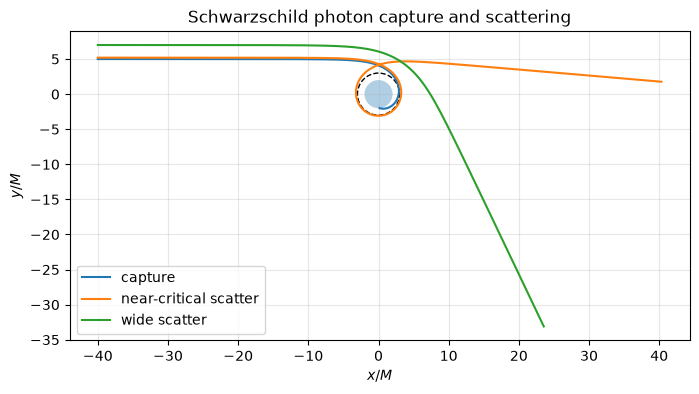

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))

for label, _ in schwarzschild_cases:
    ray = schwarzschild_rays[label]
    ax.plot(
        ray[:,1],
        ray[:,2],
        label=label,
    )

# Event horizon: r = 2M
horizon = plt.Circle(
    (0.0, 0.0),
    2.0*M,
    alpha=0.35,
)

# Photon sphere: r = 3M
photon_sphere = plt.Circle(
    (0.0, 0.0),
    3.0*M,
    fill=False,
    linestyle="--",
    linewidth=1.0,
)

ax.add_patch(horizon)
ax.add_patch(photon_sphere)

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$x/M$")
ax.set_ylabel(r"$y/M$")
ax.set_title("Schwarzschild photon capture and scattering")
ax.legend()
ax.grid(True, alpha=0.3)

fig.savefig(
    FIGURE_DIR / "schwarzschild_photon_capture_scattering.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


The dashed circle marks the Schwarzschild photon sphere at \(r=3M\).
A near-critical ray can spend substantial affine time near this unstable
region before escaping or being captured.

## 3. Kerr spin changes the capture boundary

For \(a>0\), prograde and retrograde equatorial photons are not equivalent.

The incoming rays below both have the same absolute screen offset,
\(|y_0|=5M\), and begin with the same parallel direction. Since they start at
\(x<0\) and move toward \(+x\),

- \(y_0<0\) corresponds to \(L_z>0\), prograde motion;
- \(y_0>0\) corresponds to \(L_z<0\), retrograde motion.

For \(a=0.8M\), these two rays have different fates.


In [5]:
a_kerr = 0.8

kerr_cases = [
    ("prograde, y=-5M", -5.0),
    ("retrograde, y=+5M", 5.0),
]

kerr_rays = {}

for label, y0 in kerr_cases:
    ray, outcome, E, Lz = trace_parallel_ray(
        y0,
        0.0,
        a=a_kerr,
    )

    kerr_rays[label] = ray

    outcome_name = {
        CAPTURED: "captured",
        ESCAPED: "scattered/escaped",
        UNRESOLVED: "unresolved",
    }[outcome]

    r_values = np.array([
        kerr_radius(
            state[1],
            state[2],
            state[3],
            a_kerr,
        )
        for state in ray
    ])

    print(label)
    print("  outcome =", outcome_name)
    print("  Lz/E =", Lz/E)
    print("  minimum Kerr r/M =", r_values.min())


prograde, y=-5M
  outcome = scattered/escaped
  Lz/E = 5.001133903793128
  minimum Kerr r/M = 3.9200194969880706
retrograde, y=+5M
  outcome = captured
  Lz/E = -5.002976203252476
  minimum Kerr r/M = 1.5813392456601885


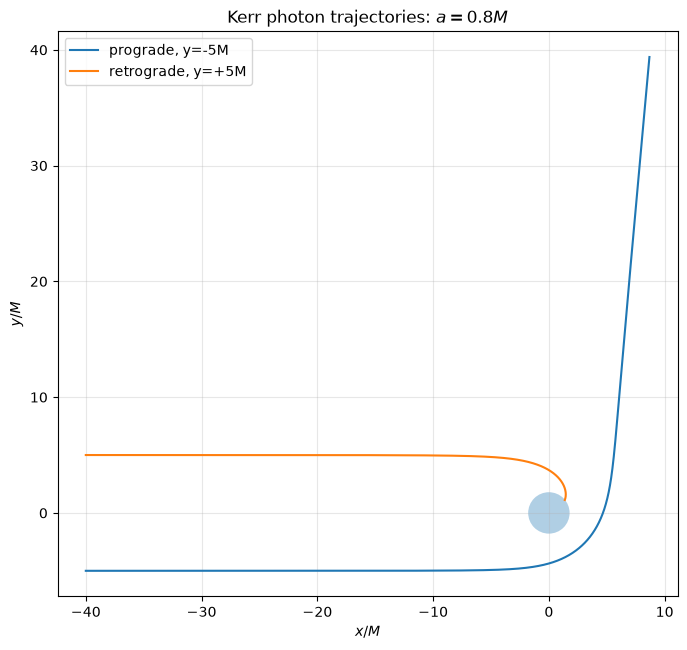

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))

for label, _ in kerr_cases:
    ray = kerr_rays[label]
    ax.plot(
        ray[:,1],
        ray[:,2],
        label=label,
    )

r_plus = horizon_radius(M, a_kerr)
horizon_xy_radius = np.sqrt(
    r_plus**2 + a_kerr**2
)

horizon = plt.Circle(
    (0.0, 0.0),
    horizon_xy_radius,
    alpha=0.35,
)

ax.add_patch(horizon)

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$x/M$")
ax.set_ylabel(r"$y/M$")
ax.set_title(
    r"Kerr photon trajectories: $a=0.8M$"
)
ax.legend()
ax.grid(True, alpha=0.3)

fig.savefig(
    FIGURE_DIR / "kerr_photon_prograde_retrograde.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


Equal-magnitude screen offsets do not produce equal outcomes once the
black hole is rotating. This asymmetry is a direct consequence of the coupling
between photon angular momentum and Kerr spin.

## 4. Schwarzschild parallel-ray capture map

A grid of initially parallel rays is launched from \(x=-30M\). Each ray is
classified as captured or escaped.

For a distant Schwarzschild black hole, the capture boundary approaches a
circle with radius

\[
b_{\rm crit}=3\sqrt{3}\,M.
\]

The finite launch distance introduces a small difference from the ideal
infinite-distance result.


In [7]:
y_screen = np.linspace(
    -8.0,
    8.0,
    81,
)

z_screen = np.linspace(
    -8.0,
    8.0,
    81,
)

capture_schw = parallel_capture_map(
    y_screen,
    z_screen,
    M=M,
    a=0.0,
    x0=-30.0,
    h=0.03,
    n_steps=4000,
)

unique, counts = np.unique(
    capture_schw,
    return_counts=True,
)

print(
    "outcome counts:",
    dict(zip(unique.tolist(), counts.tolist()))
)


outcome counts: {0: 4460, 1: 2101}


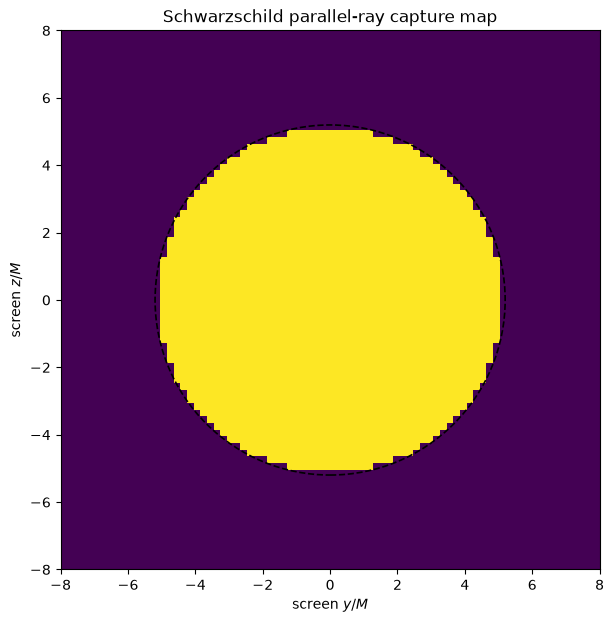

In [8]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.imshow(
    capture_schw,
    origin="lower",
    extent=[
        y_screen.min(),
        y_screen.max(),
        z_screen.min(),
        z_screen.max(),
    ],
    interpolation="nearest",
)

b_crit = 3.0*np.sqrt(3.0)*M

analytic_boundary = plt.Circle(
    (0.0, 0.0),
    b_crit,
    fill=False,
    linestyle="--",
    linewidth=1.2,
)

ax.add_patch(analytic_boundary)

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"screen $y/M$")
ax.set_ylabel(r"screen $z/M$")
ax.set_title(
    "Schwarzschild parallel-ray capture map"
)

fig.savefig(
    FIGURE_DIR / "schwarzschild_parallel_capture_map.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


## 5. Kerr parallel-ray capture map

The same screen and launch geometry are now used for \(a=0.8M\).

For an observer in the equatorial plane, the capture silhouette is no longer
centered and circular in the same way as the Schwarzschild case. Frame
dragging changes the prograde and retrograde capture boundaries differently.


In [9]:
capture_kerr = parallel_capture_map(
    y_screen,
    z_screen,
    M=M,
    a=0.8,
    x0=-30.0,
    h=0.03,
    n_steps=4000,
)

unique, counts = np.unique(
    capture_kerr,
    return_counts=True,
)

print(
    "outcome counts:",
    dict(zip(unique.tolist(), counts.tolist()))
)


outcome counts: {0: 4539, 1: 2022}


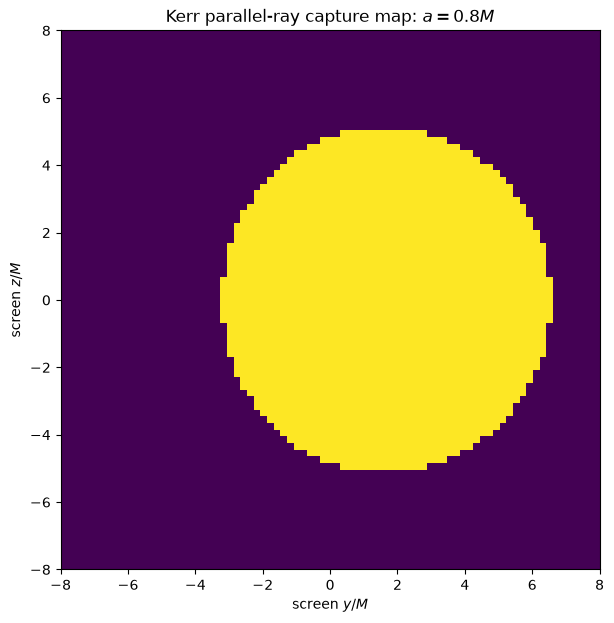

In [10]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.imshow(
    capture_kerr,
    origin="lower",
    extent=[
        y_screen.min(),
        y_screen.max(),
        z_screen.min(),
        z_screen.max(),
    ],
    interpolation="nearest",
)

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"screen $y/M$")
ax.set_ylabel(r"screen $z/M$")
ax.set_title(
    r"Kerr parallel-ray capture map: $a=0.8M$"
)

fig.savefig(
    FIGURE_DIR / "kerr_parallel_capture_map.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


## Interpretation

The photon calculations complete the original trajectory project in three
ways.

First, the same numerical geodesic engine successfully evolves both timelike
and null worldlines. Second, the Schwarzschild calculations reproduce the
expected transition between photon capture and scattering near the critical
impact parameter. Third, Kerr spin introduces a clear prograde/retrograde
capture asymmetry and shifts the parallel-ray capture silhouette.

The capture maps are deliberately simple. A full ray tracer would define an
observer tetrad, map each image-plane direction to a local photon four-momentum,
and may include an emitting surface or radiative-transfer model. That extension
is separate from the present reconstruction.
